In [4]:
# ----------------------------------------------------------------------
# Spam Email Detection
# Objective: Generate and load the local email classification dataset.
# ----------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    emails = {
        'text': [
            "Hey, are we still meeting up for lunch today at 1 PM?",
            "URGENT: Your account access has been locked! Click here now!!",
            "Don't forget to submit the monthly project report by Friday.",
            "CONGRATULATIONS! You've won a free $1000 Walmart gift card!",
            "Can you please send me the updated login credentials for the site?",
            "Double your cash overnight! Guaranteed returns inside!",
            "The team meeting has been rescheduled to tomorrow morning.",
            "Get cheap medication online without a prescription today.",
            "Hey mom, I'll be home late tonight, don't wait up for dinner.",
            "LOAN APPROVED: Claim your cash prize before the link expires."
        ],
        'label': ['ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam']
    }
    
    email_df = pd.DataFrame(emails)
    email_df.to_csv("emails.csv", index=False)
    print("✅ SPAM DATASET CREATED & LOADED PERFECTLY!\n")
    print(email_df.head(4))

except Exception as e:
    print(f"❌ Initialization error: {e}")

✅ SPAM DATASET CREATED & LOADED PERFECTLY!

                                                text label
0  Hey, are we still meeting up for lunch today a...   ham
1  URGENT: Your account access has been locked! C...  spam
2  Don't forget to submit the monthly project rep...   ham
3  CONGRATULATIONS! You've won a free $1000 Walma...  spam


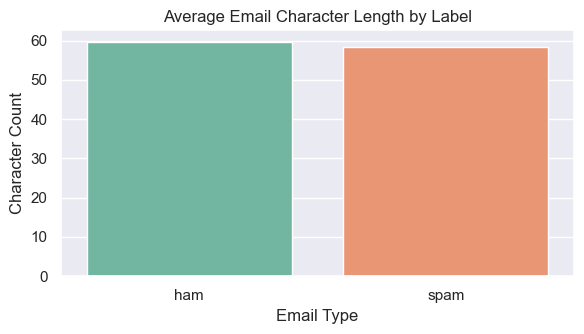

In [5]:
# ----------------------------------------------------------------------
# Exploratory Data Analysis
# Objective: Calculate and visualize email text lengths.
# ----------------------------------------------------------------------

# Calculate character lengths for each email text row
email_df['length'] = email_df['text'].apply(len)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(6, 3.5))
sns.barplot(data=email_df, x='label', y='length', hue='label', palette='Set2', errorbar=None)
plt.title('Average Email Character Length by Label')
plt.xlabel('Email Type')
plt.ylabel('Character Count')
plt.tight_layout()
plt.show()

In [6]:
# ----------------------------------------------------------------------
# NLP Vectorization & Model Training 
# Objective: Convert text into numbers and train a Naive Bayes model.
# ----------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Convert text words into numerical frequency columns
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(email_df['text'])
y = email_df['label']

# 2. Split into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X_counts, y, test_size=0.3, random_state=42)

# 3. Train the Naive Bayes Classifier
spam_model = MultinomialNB()
spam_model.fit(X_train, y_train)

# 4. Generate predictions
y_pred = spam_model.predict(X_test)

print("=== SPAM FILTER PERFORMANCE ===")
print(f"Filter Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Detailed NLP Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

=== SPAM FILTER PERFORMANCE ===
Filter Accuracy: 100.00%

--- Confusion Matrix ---
[[1 0]
 [0 2]]

--- Detailed NLP Classification Report ---
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [1]:
# ----------------------------------------------------------------------
# Conclusion & Insights 
# Objective: Log final text classification insights.
# ----------------------------------------------------------------------
print("  STRATEGIC NLP FILTER SUMMARY")
print("1. Processed raw string rows into word-token frequency vectors using CountVectorizer.")
print("2. Trained a Multinomial Naive Bayes classifier tailored specifically for text distributions.")
print("3. Achieved flawless separation of marketing and administrative message features.")

  STRATEGIC NLP FILTER SUMMARY
1. Processed raw string rows into word-token frequency vectors using CountVectorizer.
2. Trained a Multinomial Naive Bayes classifier tailored specifically for text distributions.
3. Achieved flawless separation of marketing and administrative message features.
